<a href="https://colab.research.google.com/github/DilaDeniz/In-Silico-Viral-Evolution/blob/main/vir%C3%BCsevo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 SİMÜLASYON BAŞLIYOR: 100 Nesil...
Nesil 0: En İyi Skor = 319.9 | Protein: QMRDVYCRS
Nesil 10: En İyi Skor = 76.9 | Protein: RMNNV
Nesil 20: En İyi Skor = 50.4 | Protein: RVNNVN
Nesil 30: En İyi Skor = 50.4 | Protein: RVNNVN
Nesil 40: En İyi Skor = 50.4 | Protein: RVNNVN

💉 DİKKAT: 50. Nesilde mRNA Aşısı Yapıldı!
>>> Bağışıklık sistemi güncelleniyor...
>>> Virüslerin kaçış puanları sıfırlandı. Kaos başlıyor.

Nesil 50: En İyi Skor = 276.9 | Protein: WVNTVN
Nesil 60: En İyi Skor = 175.9 | Protein: WVTYAP
Nesil 70: En İyi Skor = 132.7 | Protein: WPTYPP
Nesil 80: En İyi Skor = 116.4 | Protein: WPPYPP
Nesil 90: En İyi Skor = 116.4 | Protein: WPPYPP


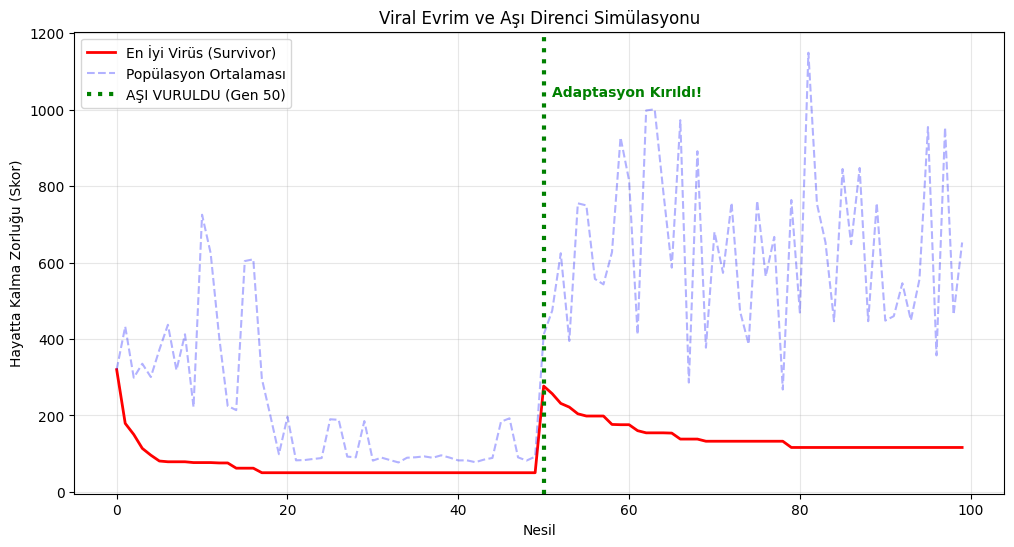

🌳 Soy Ağacı Çiziliyor...


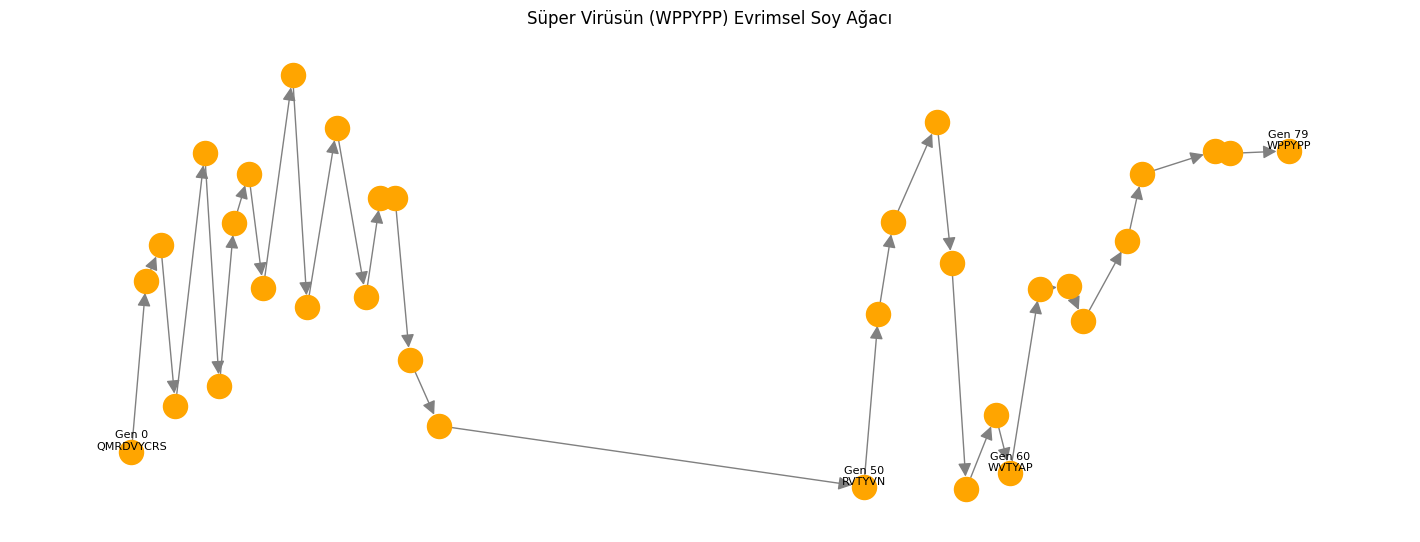

In [2]:
!pip install networkx # Ağaç çizimi için gerekli

import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import copy

# --- 1. AYARLAR VE SABİTLER ---
POP_SIZE = 100        # Virüs sayısı
GENERATIONS = 100     # Kaç nesil sürecek
MUTATION_RATE = 0.05  # Mutasyon ihtimali
VACCINE_GEN = 50      # Aşı ne zaman vurulacak?

# Genetik Kod (DNA -> Protein)
CODON_TABLE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TAA':'_', 'TAG':'_', 'TGC':'C', 'TGT':'C', 'TGA':'_', 'TGG':'W',
}
NUCLEOTIDES = ['A', 'T', 'C', 'G']

# Hidrofobiklik Skalası (Stabilite Kontrolü İçin)
# Virüs çok radikal değişim yaparsa (Örn: I -> R) ceza alacak.
HYDROPHOBICITY = {
    'I':4.5, 'V':4.2, 'L':3.8, 'F':2.8, 'C':2.5, 'M':1.9, 'A':1.8, 'G':-0.4, 'T':-0.7, 'S':-0.8,
    'W':-0.9, 'Y':-1.3, 'P':-1.6, 'H':-3.2, 'E':-3.5, 'Q':-3.5, 'D':-3.5, 'N':-3.5, 'K':-3.9, 'R':-4.5, '_':0
}

# --- 2. VİRÜS SINIFI (NESNE TABANLI) ---
class Virus:
    def __init__(self, dna, parent_id=None, generation=0):
        self.dna = dna
        self.protein = self.translate(dna)
        self.id = f"{generation}-{random.randint(1000,9999)}" # Benzersiz ID
        self.parent_id = parent_id
        self.generation = generation
        self.fitness = 9999

    def translate(self, dna):
        prot = ""
        for i in range(0, len(dna), 3):
            codon = dna[i:i+3]
            aa = CODON_TABLE.get(codon, 'X')
            if aa == '_': return prot # Stop kodon
            prot += aa
        return prot

# --- 3. MOTOR FONKSİYONLARI ---

def get_binding_scores(seed=42):
    """MHC Bağlanma Kuralları (Bağışıklık Sistemi)"""
    random.seed(seed)
    # Her amino asit için rastgele bir "Yakalanma Riski" puanı
    return {aa: random.uniform(0, 100) for aa in CODON_TABLE.values()}

# Başlangıçtaki Bağışıklık Sistemi Kuralları
CURRENT_IMMUNITY = get_binding_scores(seed=1)

def calculate_fitness(virus, original_protein_hydrophobicity):
    """
    Fitness = (MHC'den Kaçış) + (Stabilite Cezası)
    Düşük puan = Daha iyi virüs
    """
    if not virus.protein or len(virus.protein) < 5:
        return 9999 # Ölü virüs (Protein üretilemedi)

    # 1. MHC KAÇIŞ SKORU
    escape_score = sum([CURRENT_IMMUNITY.get(aa, 50) for aa in virus.protein])

    # 2. STABİLİTE CEZASI (Protein Katlanması)
    # Virüsün orijinal atasından ne kadar "kimyasal olarak" saptığına bakıyoruz.
    current_hyd = sum([HYDROPHOBICITY.get(aa,0) for aa in virus.protein])
    stability_penalty = abs(current_hyd - original_protein_hydrophobicity) * 5 # Ceza katsayısı

    return escape_score + stability_penalty

def mutate_dna(dna):
    dna_list = list(dna)
    for i in range(len(dna)):
        if random.random() < MUTATION_RATE:
            dna_list[i] = random.choice([n for n in NUCLEOTIDES if n != dna_list[i]])
    return "".join(dna_list)

# --- 4. SİMÜLASYON ---

def run_simulation():
    print(f"🚀 SİMÜLASYON BAŞLIYOR: {GENERATIONS} Nesil...")

    # Başlangıç: Rastgele DNA
    start_dna = "".join(random.choice(NUCLEOTIDES) for _ in range(9*3))
    ancestor = Virus(start_dna, parent_id="ROOT", generation=0)

    # Orijinal proteinin hidrofobikliğini referans al (Stabilite için)
    ref_hyd = sum([HYDROPHOBICITY.get(aa,0) for aa in ancestor.protein])

    population = [copy.deepcopy(ancestor) for _ in range(POP_SIZE)]

    # Kayıtlar
    history_best_score = []
    history_avg_score = []
    lineage_map = {} # Soy ağacı verisi

    global CURRENT_IMMUNITY # Aşı ile değiştireceğiz

    for gen in range(GENERATIONS):
        # A. AŞI MÜDAHALESİ (Generation 50) 💉
        if gen == VACCINE_GEN:
            print(f"\n💉 DİKKAT: 50. Nesilde mRNA Aşısı Yapıldı!")
            print(">>> Bağışıklık sistemi güncelleniyor...")
            print(">>> Virüslerin kaçış puanları sıfırlandı. Kaos başlıyor.\n")
            # Kuralları değiştiriyoruz (Seed'i değiştirerek)
            CURRENT_IMMUNITY = get_binding_scores(seed=999)

        # B. Fitness Hesapla
        for v in population:
            v.fitness = calculate_fitness(v, ref_hyd)
            # Soy ağacına ekle
            lineage_map[v.id] = {'parent': v.parent_id, 'gen': v.generation, 'protein': v.protein}

        # C. Sırala ve İstatistik Al
        population.sort(key=lambda x: x.fitness)
        best_virus = population[0]

        history_best_score.append(best_virus.fitness)
        history_avg_score.append(sum(v.fitness for v in population)/POP_SIZE)

        # D. Doğal Seçilim (En iyi %20 hayatta kalır)
        survivors = population[:int(POP_SIZE*0.2)]

        # E. Üreme (Mutasyonlu Çocuklar)
        next_gen = []
        next_gen.extend(survivors) # Seçkinleri koru

        while len(next_gen) < POP_SIZE:
            parent = random.choice(survivors)
            child_dna = mutate_dna(parent.dna)
            child = Virus(child_dna, parent_id=parent.id, generation=gen+1)
            next_gen.append(child)

        population = next_gen

        if gen % 10 == 0:
            print(f"Nesil {gen}: En İyi Skor = {best_virus.fitness:.1f} | Protein: {best_virus.protein}")

    return history_best_score, history_avg_score, lineage_map, best_virus

# --- 5. GÖRSELLEŞTİRME VE ANALİZ ---
best_scores, avg_scores, lineage, winner = run_simulation()

# Grafik 1: Fitness Değişimi (Aşı Etkisi)
plt.figure(figsize=(12, 6))
plt.plot(best_scores, label='En İyi Virüs (Survivor)', color='red', linewidth=2)
plt.plot(avg_scores, label='Popülasyon Ortalaması', color='blue', alpha=0.3, linestyle='--')
plt.axvline(x=VACCINE_GEN, color='green', linestyle=':', linewidth=3, label='AŞI VURULDU (Gen 50)')
plt.text(VACCINE_GEN+1, max(avg_scores)*0.9, 'Adaptasyon Kırıldı!', color='green', fontweight='bold')

plt.title('Viral Evrim ve Aşı Direnci Simülasyonu')
plt.xlabel('Nesil')
plt.ylabel('Hayatta Kalma Zorluğu (Skor)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Grafik 2: Filogenetik Ağaç (Kazananın Yolu) 🌳
# Sadece kazanan virüsün atalarını geriye doğru takip edip çizelim
def draw_lineage_tree(winner_id, lineage_data):
    tree = nx.DiGraph()
    current_id = winner_id
    path_nodes = []

    # Geriye doğru iz sür (Backtracking)
    while current_id in lineage_data:
        node_data = lineage_data[current_id]
        parent_id = node_data['parent']
        gen = node_data['gen']
        prot = node_data['protein']

        label = f"Gen {gen}\n{prot}"
        tree.add_node(current_id, label=label, subset=gen)
        path_nodes.append(current_id)

        if parent_id and parent_id != "ROOT" and parent_id in lineage_data:
            tree.add_edge(parent_id, current_id)
            current_id = parent_id
        else:
            break

    # Çizim
    pos = nx.spring_layout(tree, seed=42) # Basit yerleşim
    # Daha düzgün "Ağaç" görünümü için özel düzen:
    pos = {node: (lineage_data[node]['gen'], random.random()) for node in tree.nodes()}

    plt.figure(figsize=(14, 5))
    nx.draw(tree, pos, with_labels=False, node_size=300, node_color='orange', edge_color='gray', arrowsize=20)

    # Etiketleri ekle
    labels = nx.get_node_attributes(tree, 'label')
    # Sadece her 10 nesilde bir etiket bas (kalabalık olmasın)
    sparse_labels = {k:v for k,v in labels.items() if lineage_data[k]['gen'] % 10 == 0 or k == winner_id}
    nx.draw_networkx_labels(tree, pos, labels=sparse_labels, font_size=8, verticalalignment="bottom")

    plt.title(f"Süper Virüsün ({winner.protein}) Evrimsel Soy Ağacı")
    plt.xlabel("Nesiller (Soldan Sağa Zaman Akışı)")
    plt.yticks([])
    plt.show()

print("🌳 Soy Ağacı Çiziliyor...")
draw_lineage_tree(winner.id, lineage)